<h1 style="text-align:center; font-weight:700; margin-bottom:5px; color:#1a237e;">
Credit Card Fraud Detection
</h1>
<p style="text-align:center; font-size:16px; color:#424242;">
Project
</p>

## Import Libraries

In [103]:
import warnings
warnings.filterwarnings("ignore")
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme()
import plotly.express as px
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
from math import radians, sin, cos, sqrt, atan2
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool


## Load Data

In [104]:
data = pd.read_csv("credit_card_fraud.csv")
data.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


## Data Overview

In [105]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [106]:
data.duplicated().sum()

0

In [107]:
data.isna().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [108]:
object_cols = data.select_dtypes(include=['object']).columns
selected_df = data[object_cols.drop(['trans_num','merchant','dob',])]
for unique in selected_df:
    val = data[unique].unique()
    print(f"Column Name : {unique} \n Unique entries : {val}")
    print("_"*100)

Column Name : trans_date_trans_time 
 Unique entries : ['2019-01-01 00:00:44' '2019-01-01 00:00:51' '2019-01-01 00:07:27' ...
 '2020-12-31 23:59:07' '2020-12-31 23:59:15' '2020-12-31 23:59:24']
____________________________________________________________________________________________________
Column Name : category 
 Unique entries : ['grocery_pos' 'entertainment' 'shopping_pos' 'misc_pos' 'shopping_net'
 'gas_transport' 'misc_net' 'grocery_net' 'food_dining' 'health_fitness'
 'kids_pets' 'home' 'personal_care' 'travel']
____________________________________________________________________________________________________
Column Name : city 
 Unique entries : ['Orient' 'Malad City' 'Grenada' 'High Rolls Mountain Park' 'Freedom'
 'Honokaa' 'Valentine' 'Westfir' 'Thompson' 'Conway' 'Athena' 'San Jose'
 'Ravenna' 'Parks' 'Fort Washakie' 'Littleton' 'Meadville' 'Moab'
 'Hawthorne' 'Manville' 'June Lake' 'Sixes' 'Holstein' 'Westerville'
 'Ballwin' 'Fields Landing' 'Louisiana' 'Kansas City' '

In [109]:
data.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


## Train-Test Split to Prevent Data Leakage

Before building the model, the dataset was divided into **training** and **testing** sets.This step is crucial to prevent **data leakage** and ensure an accurate evaluation of the model.  
Although the number of features is currently limited, during **feature engineering** we will create many new features. If the data is not properly split beforehand, these engineered features could inadvertently introduce **data leakage**, leading to overly optimistic performance estimates.


In [110]:
X = data.drop("is_fraud", axis="columns")
y = data['is_fraud']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

print(df_train.shape)
df_train.head(2)

(254705, 15)


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
295246,2020-10-18 19:38:13,Gerhold LLC,home,35.46,Moriarty,NM,34.9889,-106.0609,7268,"Therapist, art",1988-08-04,cdde77c07a3d9d082989ad271aeb0b0d,35.545397,-106.501270,0
9531,2019-01-31 07:34:11,Dach-Bore,grocery_net,43.82,Sun City,CA,33.7467,-117.1721,54287,"Designer, exhibition/display",1972-09-22,c97c376d2db4cb893259b485a96ca901,32.760022,-117.874444,0


## Extracting Date-Time Components

In [111]:
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])

df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['day'] = df_train['trans_date_trans_time'].dt.day
df_train['weekday'] = df_train['trans_date_trans_time'].dt.weekday
df_train['month'] = df_train['trans_date_trans_time'].dt.month
df_train['year'] = df_train['trans_date_trans_time'].dt.year

df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])

df_test['hour'] = df_test['trans_date_trans_time'].dt.hour
df_test['day'] = df_test['trans_date_trans_time'].dt.day
df_test['weekday'] = df_test['trans_date_trans_time'].dt.weekday
df_test['month'] = df_test['trans_date_trans_time'].dt.month
df_test['year'] = df_test['trans_date_trans_time'].dt.year

### Calculate Age

In [112]:
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_train['age'] = (pd.Timestamp.now() - df_train['dob']).dt.days // 365

df_test['dob'] = pd.to_datetime(df_test['dob'])
df_test['age'] = (pd.Timestamp.now() - df_test['dob']).dt.days // 365

In [113]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254705 entries, 295246 to 307251
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  254705 non-null  datetime64[ns]
 1   merchant               254705 non-null  object        
 2   category               254705 non-null  object        
 3   amt                    254705 non-null  float64       
 4   city                   254705 non-null  object        
 5   state                  254705 non-null  object        
 6   lat                    254705 non-null  float64       
 7   long                   254705 non-null  float64       
 8   city_pop               254705 non-null  int64         
 9   job                    254705 non-null  object        
 10  dob                    254705 non-null  datetime64[ns]
 11  trans_num              254705 non-null  object        
 12  merch_lat              254705 non-null  floa

### Feature Type Separation

In [114]:
continuous_col = df_train.select_dtypes(include=['int64','float64','int32']).columns
categorical_col = df_train.select_dtypes(include = ['object']).columns


## Boxplot-Based Outlier Analysis

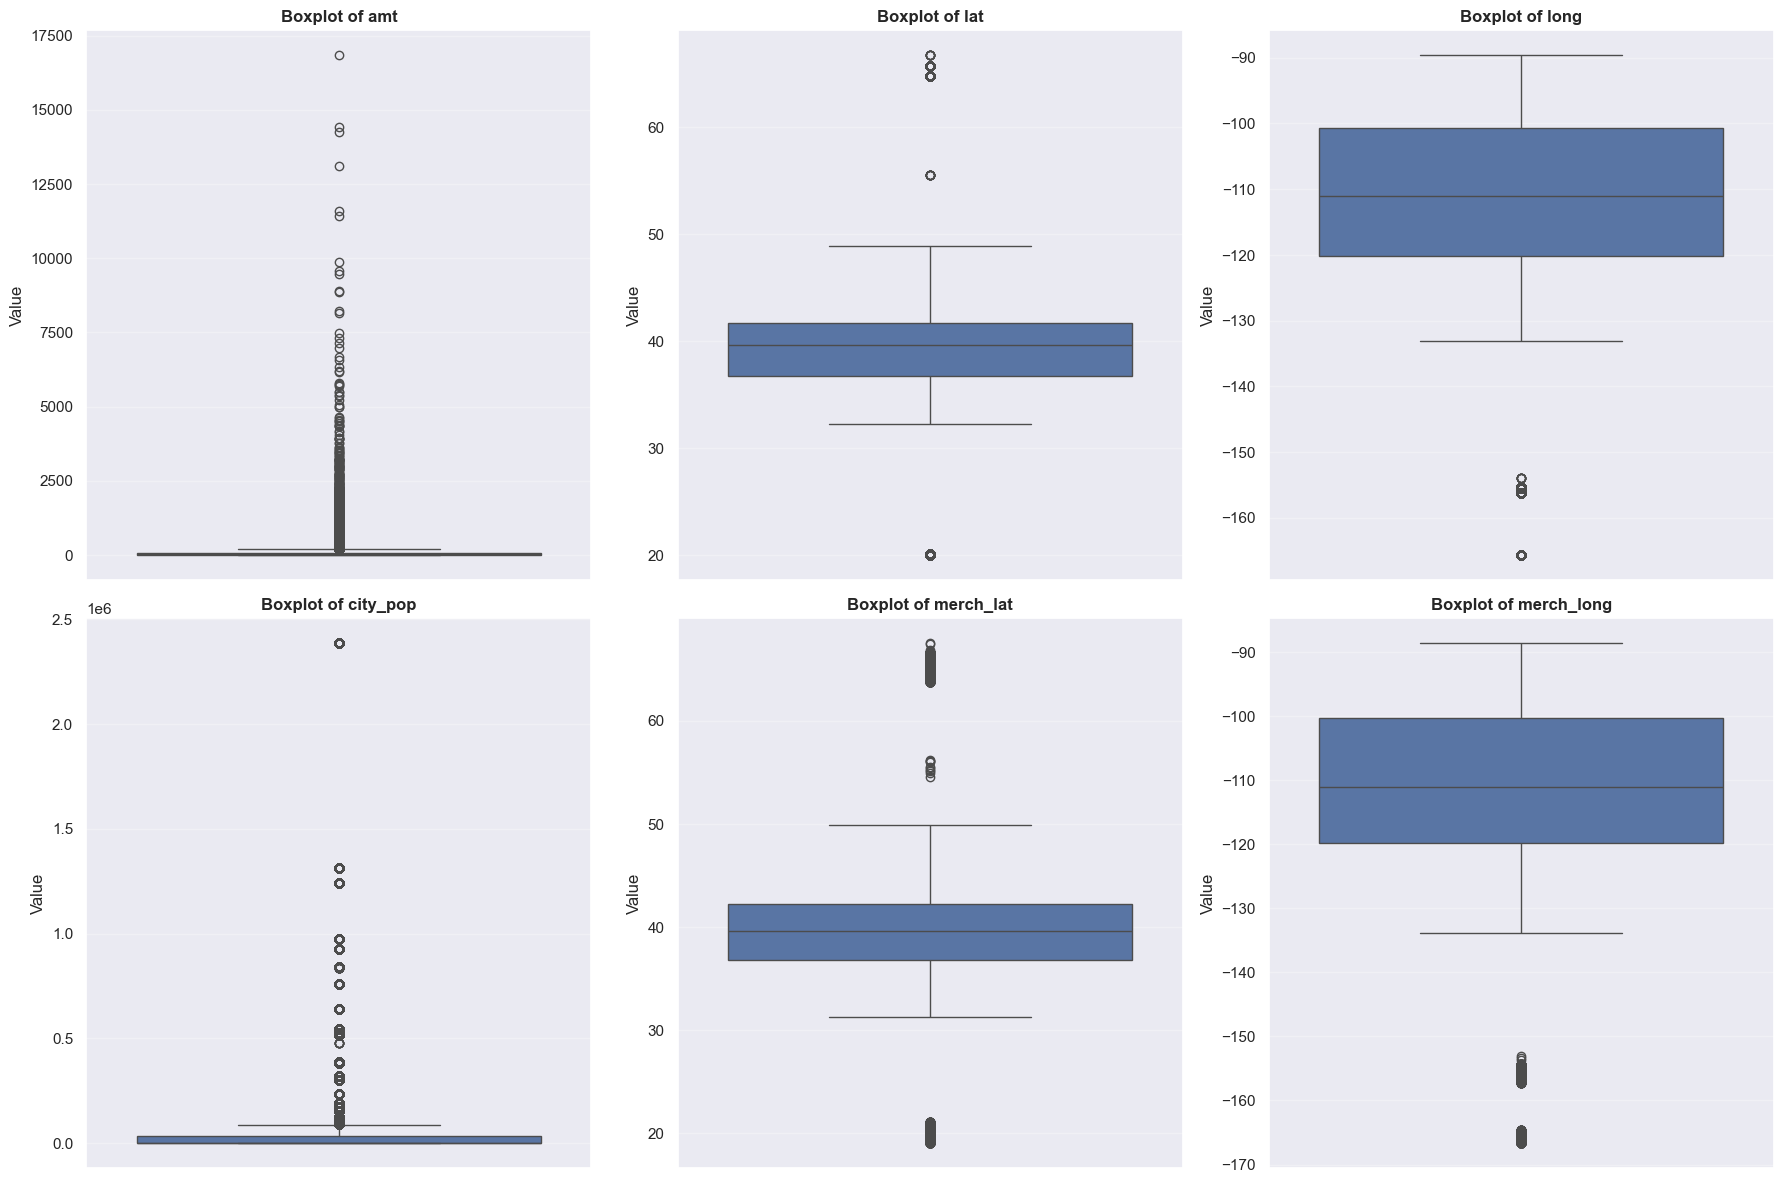

In [115]:
continuous_col_box = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']

fig, axes = plt.subplots(2, 3, figsize=(18,12))

axes = axes.flatten()

for i, col in enumerate(continuous_col_box):
    sns.boxplot(y=df_train[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()
plt.close()

##### their is some outliers are detected but we will not treat them because 

<h1 style="text-align: center;">📊 Exploratory Data Analysis (EDA)</h1>

In [116]:
df_train['is_fraud'].value_counts()

is_fraud
0    253369
1      1336
Name: count, dtype: int64

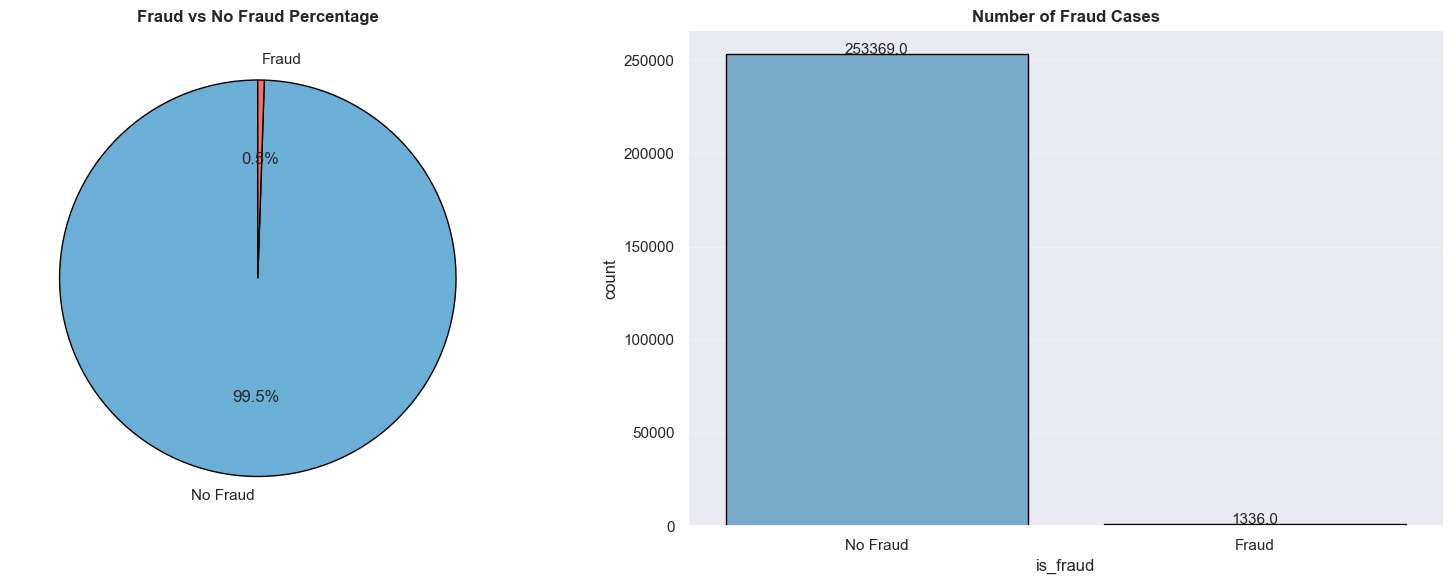

In [117]:
# Calculate percentages
fraud = len(df_train[df_train['is_fraud'] == 1]) / len(df_train) * 100
nofraud = len(df_train[df_train['is_fraud'] == 0]) / len(df_train) * 100
fraud_percentage = [nofraud, fraud]

# Elegant color palette
colors = ['#6BAED6', '#FF6F61']  # soft blue + coral red

# Create 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart (left column)
axes[0].pie(
    fraud_percentage,
    labels=['No Fraud', 'Fraud'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor':'black','linewidth':1,'antialiased':True}
)
axes[0].set_title("Fraud vs No Fraud Percentage")

# Countplot (right column)
sns.countplot(x='is_fraud', data=df_train, edgecolor='black', palette=colors, ax=axes[1])
for rect in axes[1].patches:
    axes[1].text(
        rect.get_x() + rect.get_width()/2,
        rect.get_height() + 2,
        rect.get_height(),
        ha='center', fontsize=11
    )
axes[1].set_xticklabels(['No Fraud','Fraud'])
axes[1].set_title("Number of Fraud Cases")

plt.tight_layout()
plt.show()


The dataset is highly imbalanced, with approximately 99.5% non-fraud transactions and only 0.5% fraud transactions (1,336 fraud cases out of 254,705 transactions). This severe class imbalance justifies the use of imbalance-handling techniques such as SMOTE-Tomek, Easy Ensemble, or class weighting during model training.

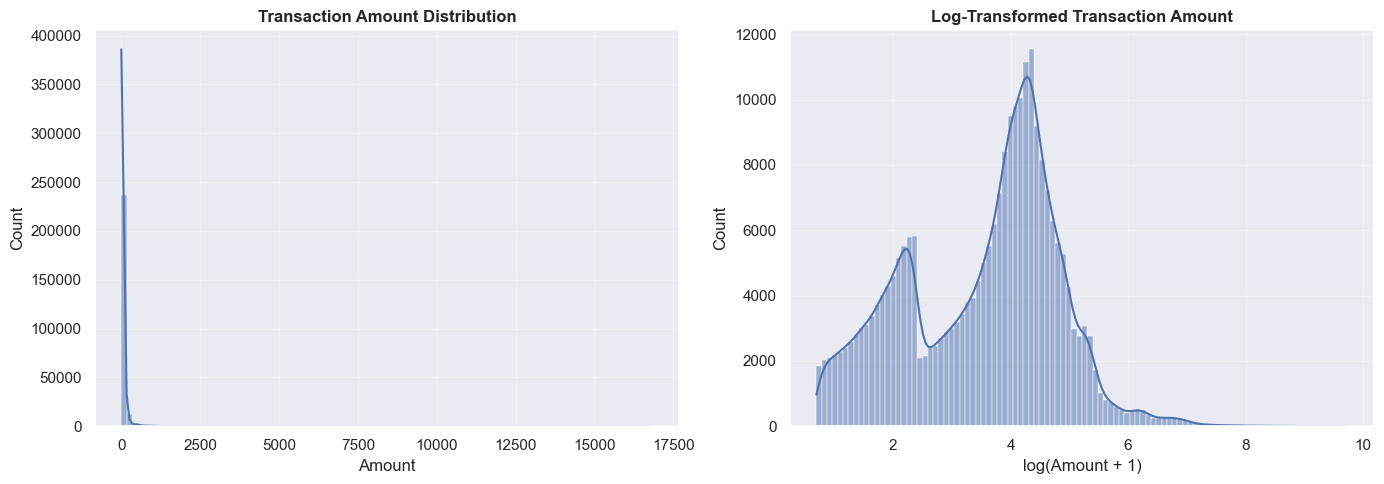

In [118]:
# Transaction Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_train,x="amt",kde=True,bins=100,ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount")

sns.histplot(x=np.log1p(df_train["amt"]),kde=True,bins=100,ax=axes[1])
axes[1].set_title("Log-Transformed Transaction Amount")
axes[1].set_xlabel("log(Amount + 1)")

plt.tight_layout()
plt.show()

In [119]:
total_amt_5000 = (df_train['amt'] >= 5000).sum()
total_amt = df_train.loc[(df_train['amt'] >= 500) | (df_train['amt'] < 5000), 'amt'].sum()
print("Transaction amt >500 and <5000 : ",total_amt)
print("Transaction amt <5000 : ",total_amt_5000)

Transaction amt >500 and <5000 :  18030845.33
Transaction amt <5000 :  32


Most transactions are below 5,000 (likely in dollars), and fraudulent transactions are also concentrated in these low-value amounts. This suggests that fraudsters often prefer smaller transactions, as they are less likely to attract immediate attention or trigger fraud detection systems.

In [120]:
bins = [0, 50, 100, 200, 500, 1000, 5000, 30000]
labels = ['0-50', '50-100', '100-200', '200-500', 
          '500-1K', '1K-5K', '5K+']

df_train['amt_bin'] = pd.cut(df_train['amt'], bins=bins, labels=labels)

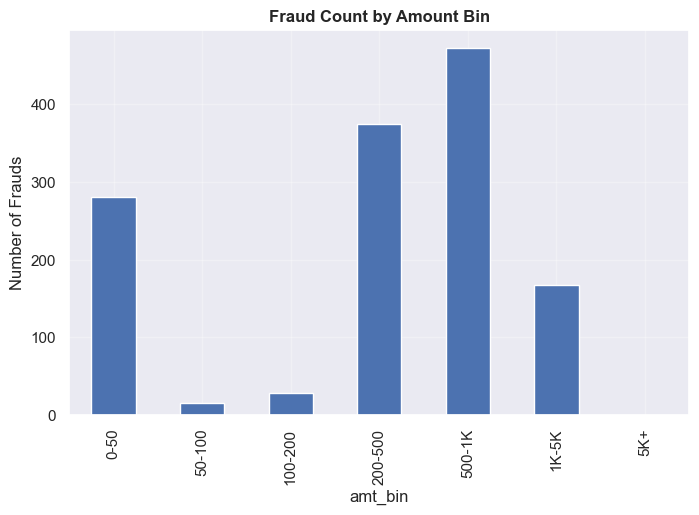

In [121]:
fraud_count = df_train[df_train['is_fraud'] == 1]['amt_bin'].value_counts()

fraud_count.sort_index().plot(kind='bar', figsize=(8,5))
plt.title("Fraud Count by Amount Bin")
plt.ylabel("Number of Frauds")
plt.show()

In [122]:
analysis = df_train.groupby('amt_bin').agg(
    total_txn=('is_fraud','count'),
    fraud_txn=('is_fraud','sum')
)

analysis['fraud_rate'] = analysis['fraud_txn'] / analysis['total_txn']

print(analysis)

         total_txn  fraud_txn  fraud_rate
amt_bin                                  
0-50        133716        280    0.002094
50-100       73812         15    0.000203
100-200      34534         28    0.000811
200-500       9589        374    0.039003
500-1K        2257        472    0.209127
1K-5K          765        167    0.218301
5K+             32          0    0.000000


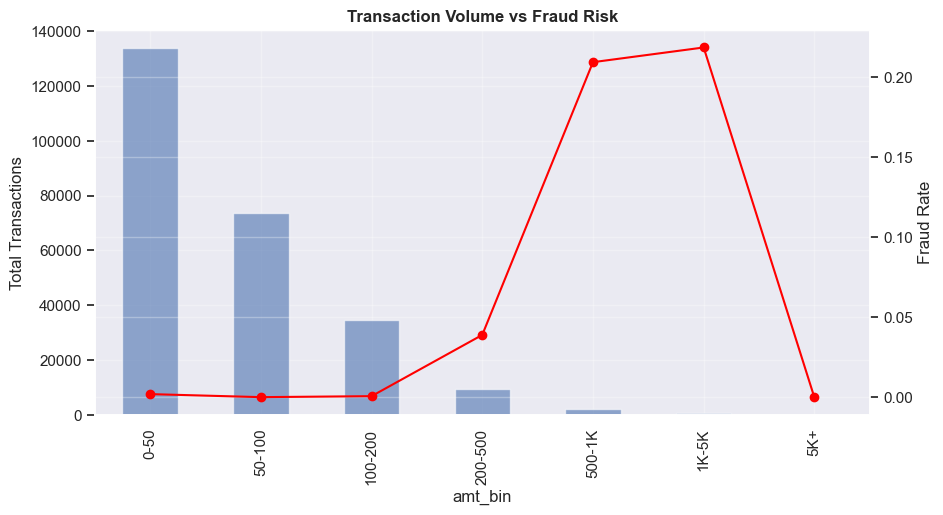

In [123]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Bar plot for total transactions
analysis['total_txn'].plot(kind='bar', ax=ax1, alpha=0.6)
ax1.set_ylabel("Total Transactions")

# Line plot for fraud rate
ax2 = ax1.twinx()
analysis['fraud_rate'].plot(color='red', marker='o', ax=ax2)
ax2.set_ylabel("Fraud Rate")

plt.title("Transaction Volume vs Fraud Risk")
plt.xticks(rotation=45)
plt.show()

amt_bin  hour
500-1K   23      0.618026
1K-5K    23      0.600000
500-1K   22      0.593525
1K-5K    22      0.571429
         0       0.400000
500-1K   0       0.382353
1K-5K    3       0.350000
         1       0.315789
         2       0.266667
500-1K   3       0.231884
dtype: float64


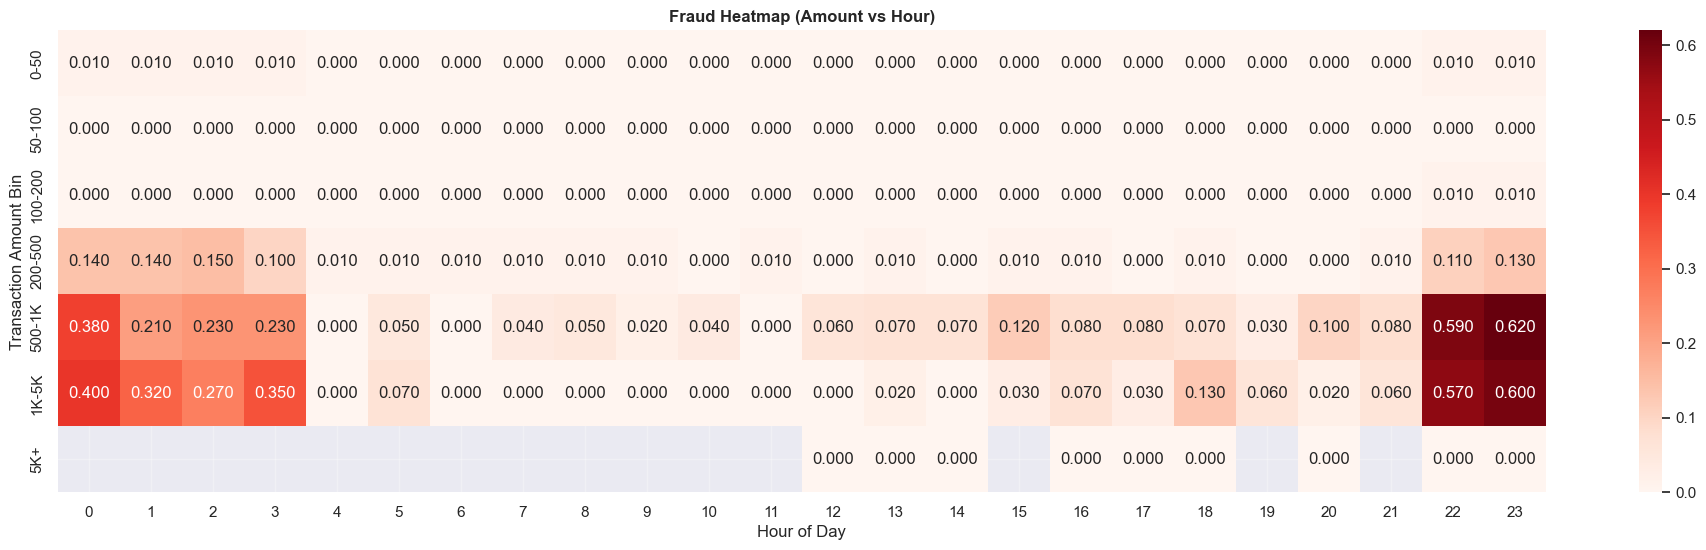

In [124]:
heatmap_data = df_train.groupby(['amt_bin','hour'])['is_fraud'].mean().unstack()
high_risk = heatmap_data.stack().sort_values(ascending=False).head(10)

print(high_risk)


plt.figure(figsize=(24,6))

sns.heatmap(round(heatmap_data,2),
            cmap='Reds',
            annot=True,
            fmt=".3f")

plt.title("Fraud Heatmap (Amount vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Amount Bin")

plt.show()

In [125]:
df_train = df_train.drop('amt_bin', axis =1)

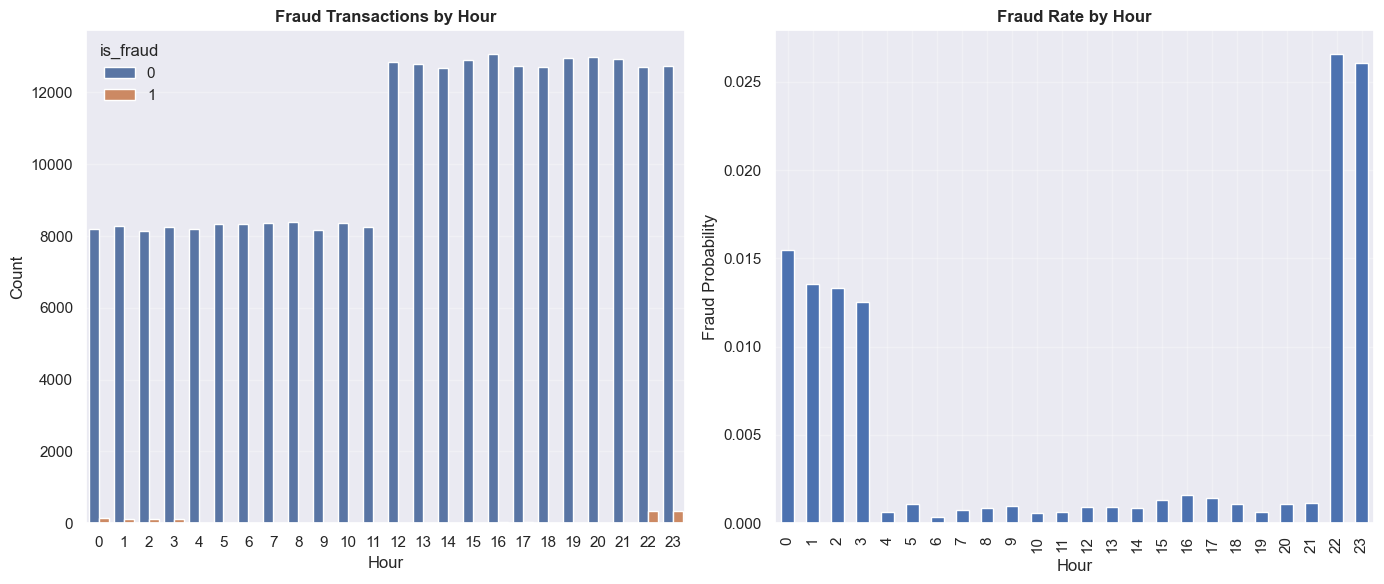

In [126]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.countplot(x='hour', hue='is_fraud', data=df_train)
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.subplot(1,2,2)
fraud_rate = df_train.groupby('hour')['is_fraud'].mean()
fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Probability")
plt.xlabel("Hour")

plt.tight_layout()
plt.show()

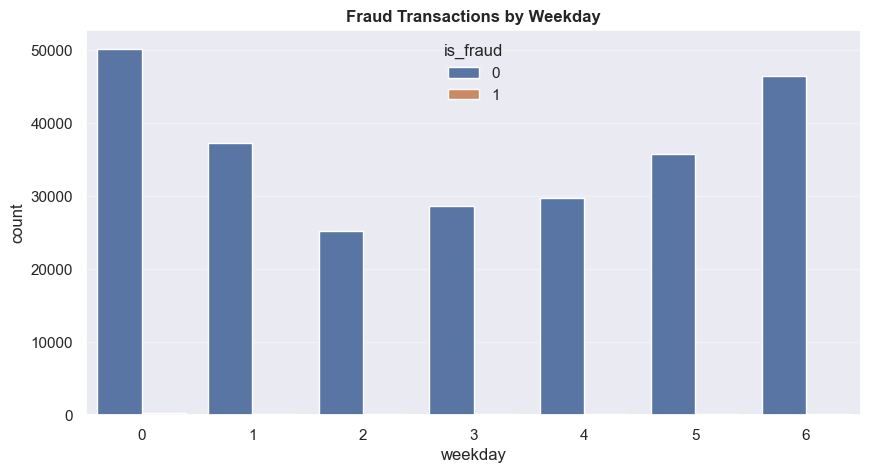

In [127]:
plt.figure(figsize=(10,5))
sns.countplot(x='weekday', hue='is_fraud', data=df_train)
plt.title("Fraud Transactions by Weekday")
plt.show()

In [128]:
fraud_weekly = (
    df_train.groupby('weekday')['is_fraud']
      .value_counts()
      .reset_index(name='count')
)

weekday_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

fraud_weekly['weekday'] = fraud_weekly['weekday'].map(weekday_map)
fraud_weekly

,weekday,is_fraud,count
0,Sunday,0,50188
1,Sunday,1,242
2,Monday,0,37257
3,Monday,1,165
4,Tuesday,0,25249
5,Tuesday,1,153
6,Wednesday,0,28699
7,Wednesday,1,147
8,Thursday,0,29776
9,Thursday,1,201


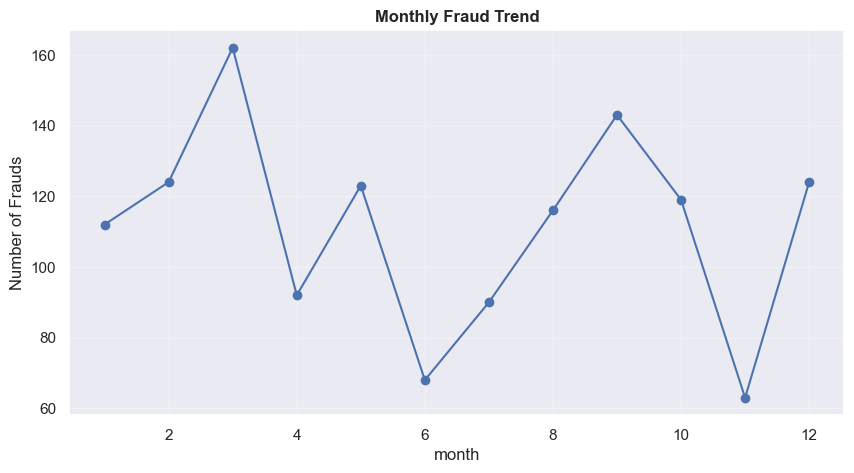

In [129]:
fraud_trend = df_train.groupby('month')['is_fraud'].sum()

fraud_trend.plot(kind='line',marker='o', figsize=(10,5))
plt.title("Monthly Fraud Trend")
plt.ylabel("Number of Frauds")
plt.show()

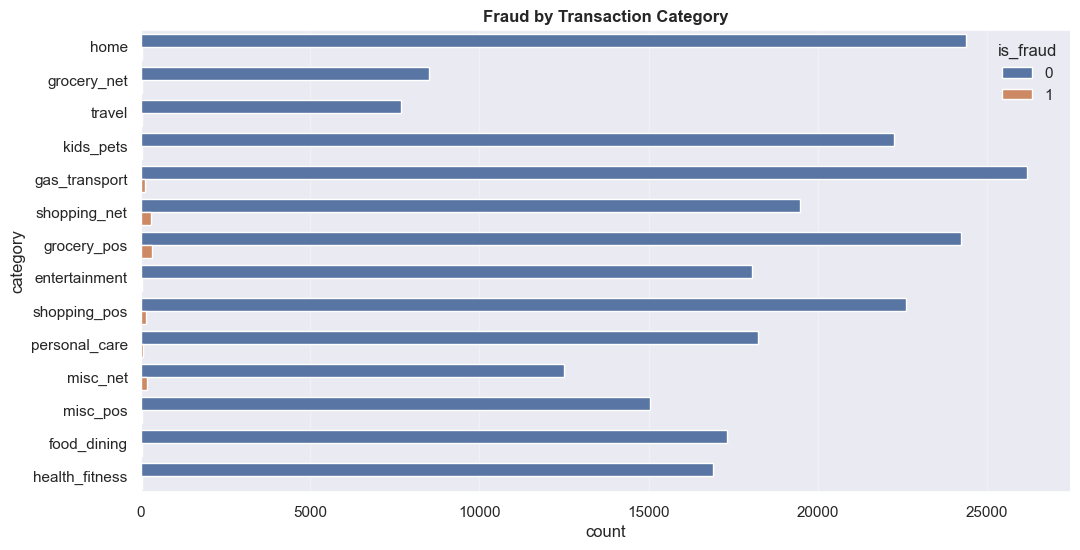

In [130]:
plt.figure(figsize=(12,6))
sns.countplot(y='category', hue='is_fraud', data=df_train)
plt.title("Fraud by Transaction Category")
plt.show()

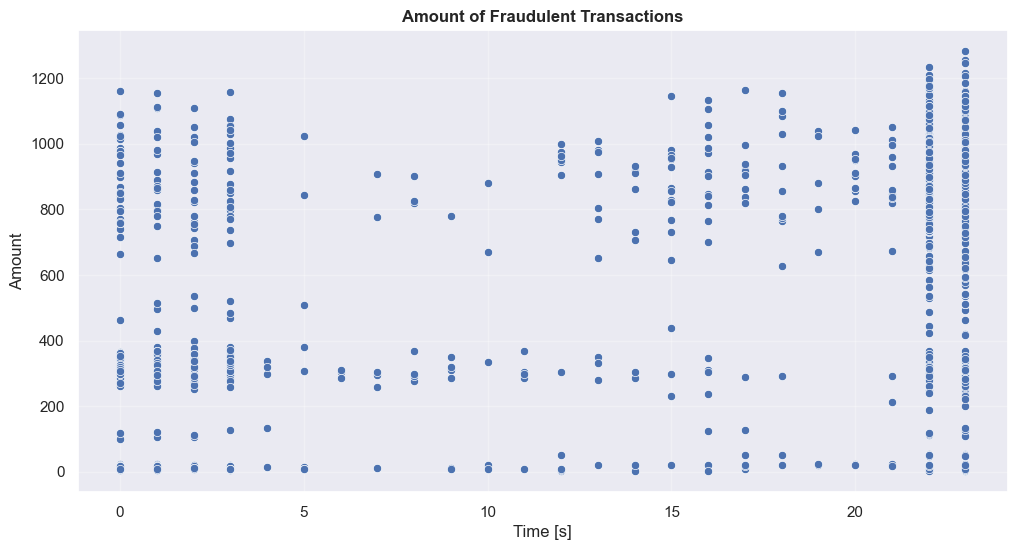

In [131]:
fraud = df_train.loc[df_train['is_fraud'] == 1]

plt.figure(figsize=(12, 6))
sns.scatterplot(x=fraud['hour'], y=fraud['amt'])
plt.title("Amount of Fraudulent Transactions")
plt.xlabel("Time [s]")
plt.ylabel("Amount")
plt.show()


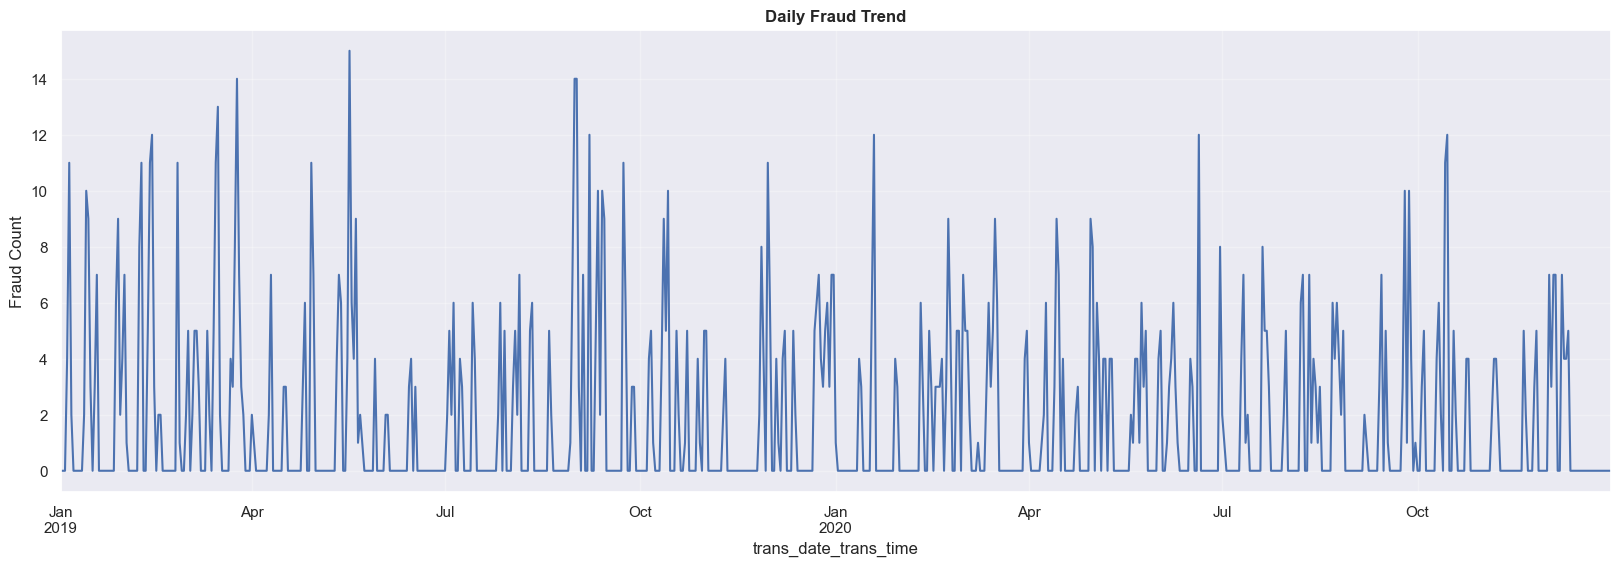

In [132]:
df_train.reset_index(inplace=True)
df_train.set_index('trans_date_trans_time', inplace=True)
fraud_time = df_train['is_fraud'].resample('D').sum()

fraud_time.plot(figsize=(20,6))
plt.title("Daily Fraud Trend")
plt.ylabel("Fraud Count")
plt.show()

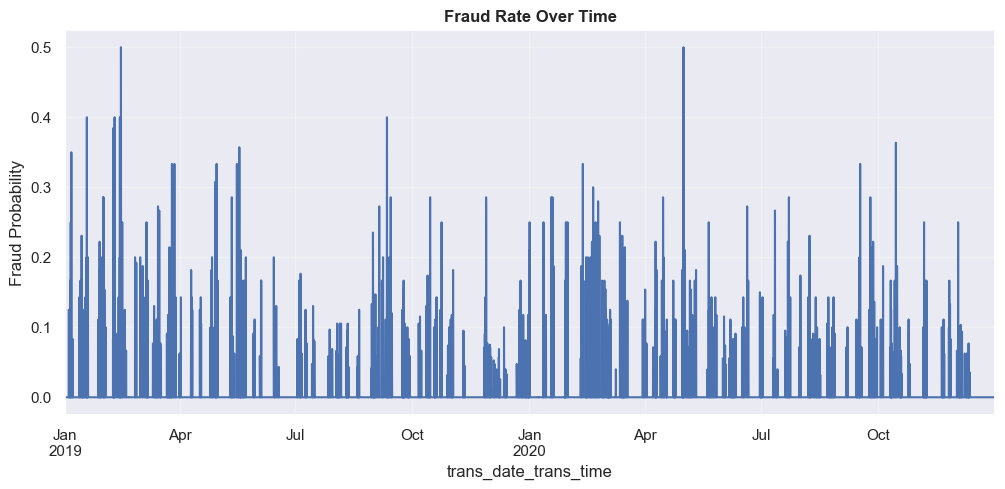

In [133]:
fraud_rate = df_train['is_fraud'].resample('H').mean()

fraud_rate.plot(figsize=(12,5))
plt.title("Fraud Rate Over Time")
plt.ylabel("Fraud Probability")
plt.show()

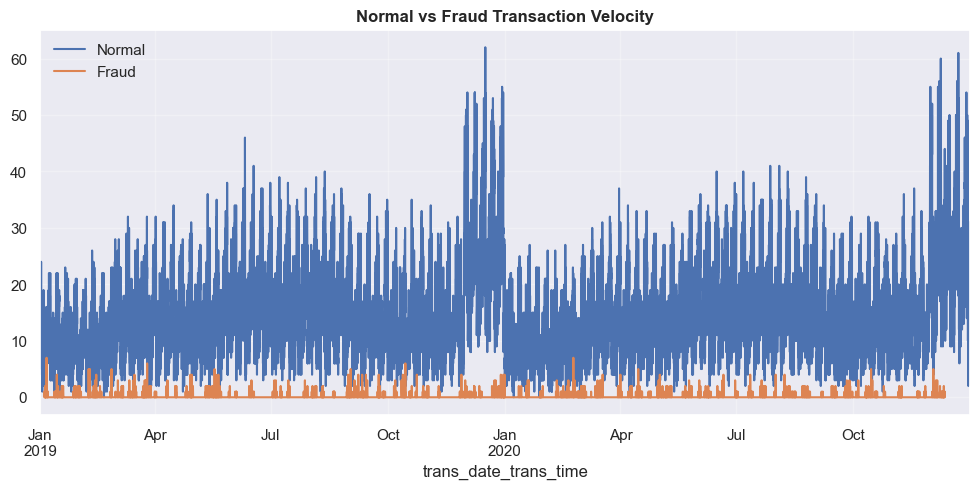

In [134]:
normal = df_train[df_train['is_fraud']==0]['amt'].resample('H').count()
fraud = df_train[df_train['is_fraud']==1]['amt'].resample('H').count()

plt.figure(figsize=(12,5))
normal.plot(label='Normal')
fraud.plot(label='Fraud')
plt.legend()
plt.title("Normal vs Fraud Transaction Velocity")
plt.show()

In [135]:
df_train.reset_index(inplace=True)

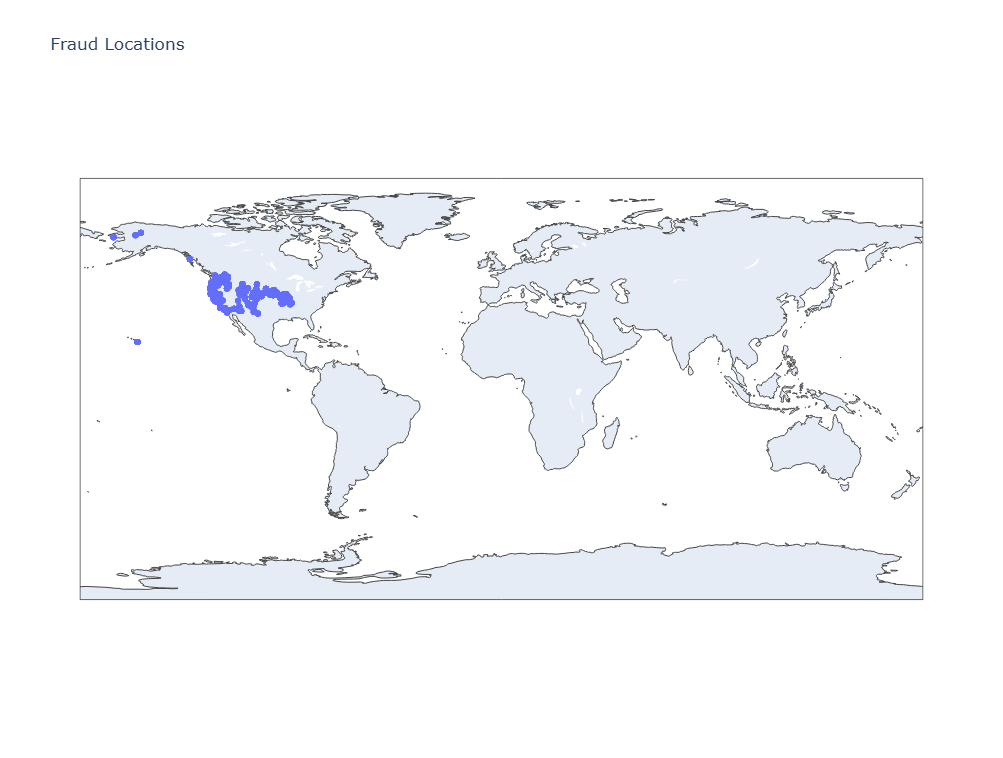

In [136]:

fig = px.scatter_geo(
    df_train[df_train['is_fraud']==1],
    lat='lat',
    lon='long',
    title='Fraud Locations',
    width=1200,   # increase width
    height=700    # increase height
)

fig.show()

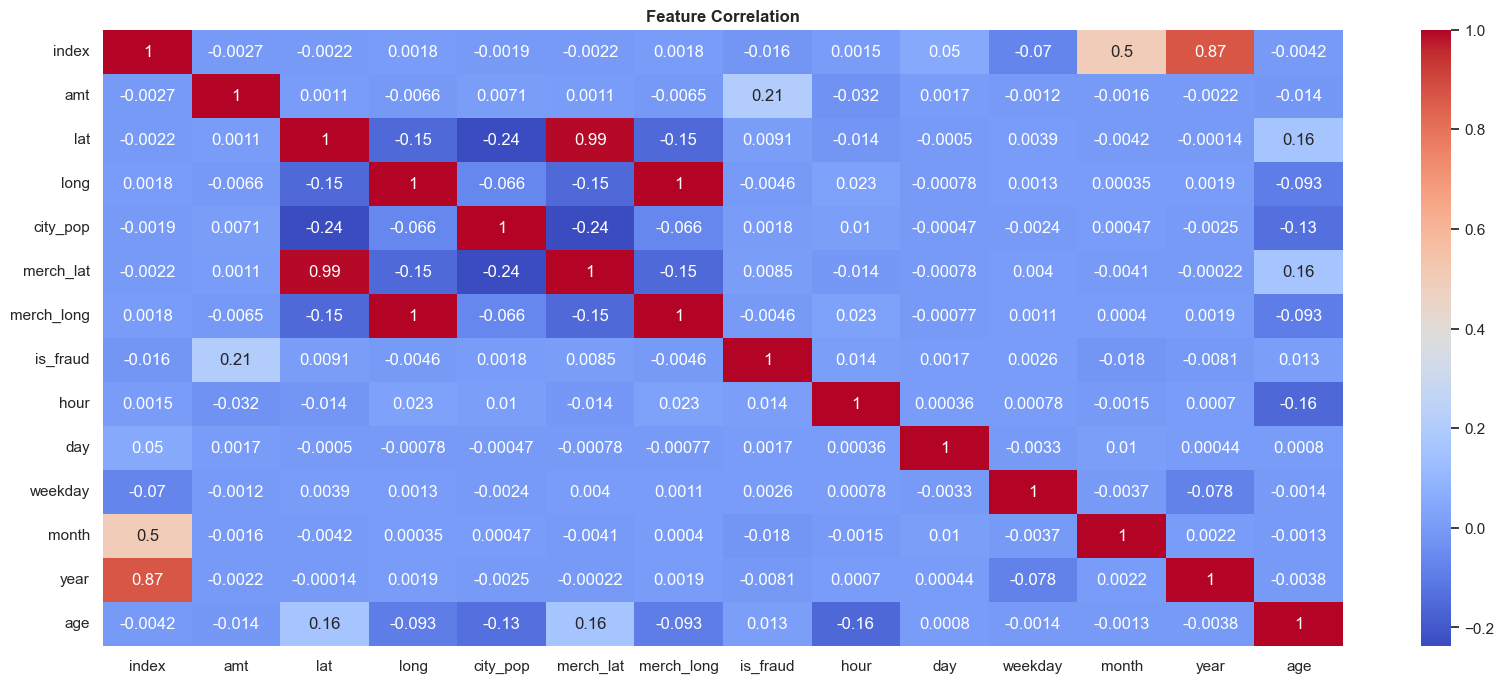

In [137]:
plt.figure(figsize=(20,8))
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

<h1 style="text-align: center;">📶 Feature Engineering </h1>

In [138]:
df_train.head()

,trans_date_trans_time,index,merchant,category,amt,city,state,lat,long,city_pop,...,trans_num,merch_lat,merch_long,is_fraud,hour,day,weekday,month,year,age
0,2020-10-18 19:38:13,295246,Gerhold LLC,home,35.46,Moriarty,NM,34.9889,-106.0609,7268,...,cdde77c07a3d9d082989ad271aeb0b0d,35.545397,-106.501270,0,19,18,6,10,2020,38
1,2019-01-31 07:34:11,9531,Dach-Bore,grocery_net,43.82,Sun City,CA,33.7467,-117.1721,54287,...,c97c376d2db4cb893259b485a96ca901,32.760022,-117.874444,0,7,31,3,1,2019,53
2,2020-07-20 15:04:27,253149,Lynch-Moh,travel,5.90,San Diego,CA,32.7185,-117.1593,1241364,...,ca8c8f7347e23ec8eaf33b34d700bda9,32.850846,-116.814953,0,15,20,0,7,2020,38
3,2019-09-25 19:59:42,116267,Rau-Grant,kids_pets,105.88,Campbell,NE,40.2967,-98.7370,493,...,1f8a6a8c426ab8fd6b968c275daec1c0,40.153194,-97.936201,0,19,25,2,9,2019,85
4,2019-12-25 02:23:49,164306,"Jenkins, Hauck and Friesen",gas_transport,43.54,Redford,MO,37.3272,-91.0243,241,...,62bdcde84a37607cd7aea5fd12a309d6,37.545586,-91.179547,0,2,25,2,12,2019,51


In [139]:
df_train.columns

Index(['trans_date_trans_time', 'index', 'merchant', 'category', 'amt', 'city',
       'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num',
       'merch_lat', 'merch_long', 'is_fraud', 'hour', 'day', 'weekday',
       'month', 'year', 'age'],
      dtype='object')

In [140]:
df_test.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'weekday', 'month', 'year',
       'age'],
      dtype='object')

In [141]:
# Separate target
y_train_set = df_train['is_fraud'].copy()
y_test_set = df_test['is_fraud'].copy()


## Feature Creation

In [142]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

df_train['distance'] = df_train.apply(lambda x: haversine(
    x['lat'], x['long'], x['merch_lat'], x['merch_long']), axis=1)

df_test['distance'] = df_test.apply(lambda x: haversine(
    x['lat'], x['long'], x['merch_lat'], x['merch_long']), axis=1)

df_train.drop(columns =[ 'merch_lat', 'merch_long','lat','long','trans_date_trans_time','merchant','index'],inplace = True)
df_test.drop(columns = ['merch_lat', 'merch_long','lat','long','trans_date_trans_time','merchant'], inplace = True)

In [143]:
print(df_train.shape)
print(df_test.shape)

(254705, 16)
(84902, 16)


In [144]:
def add_cyclical_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclical encodings for hour and weekday, plus night indicator."""
    df = df.copy()
    df['is_night'] = ((df['hour'] <= 5) | (df['hour'] >= 23)).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    return df

def add_transaction_features(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """Add transaction frequency and length features."""
    trans_freq = df_train["trans_num"].value_counts()
    
    df_train["trans_freq"] = df_train["trans_num"].map(trans_freq)
    df_test["trans_freq"] = df_test["trans_num"].map(trans_freq).fillna(0)
    return df_train, df_test

def add_time_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Add weekend, business hours, and late night flags."""
    df = df.copy()
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)
    df["business_hours"] = ((df["hour"] >= 8) & (df["hour"] <= 18)).astype(int)
    return df

def add_category_stats(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """Add category-level mean, std, and z-score features."""
    category_mean = df_train.groupby("category")["amt"].mean()
    category_std = df_train.groupby("category")["amt"].std()

    for df in [df_train, df_test]:
        df["category_avg_amt"] = df["category"].map(category_mean)
        df["category_std_amt"] = df["category"].map(category_std)
        df["category_amt_zscore"] = (
            (df["amt"] - df["category_avg_amt"]) /
            (df["category_std_amt"] + 1e-6)
        )

    return df_train, df_test

In [145]:
def feature_engineering_pipeline(df_train: pd.DataFrame, df_test: pd.DataFrame):
    # Cyclical time features
    df_train = add_cyclical_time_features(df_train)
    df_test = add_cyclical_time_features(df_test)

    # Transaction features
    df_train, df_test = add_transaction_features(df_train, df_test)

    # Time flags
    df_train = add_time_flags(df_train)
    df_test = add_time_flags(df_test)

    # Category statistics
    df_train, df_test = add_category_stats(df_train, df_test)

    return df_train, df_test

In [146]:
df_train, df_test = feature_engineering_pipeline(df_train, df_test)

In [147]:
print(len(df_train.columns))
print(len(df_test.columns))

27
27


### Handling Job Categoires

In [148]:
df_train['job'].unique()

array(['Therapist, art', 'Designer, exhibition/display', 'Comptroller',
       'Surveyor, minerals', 'Investment analyst',
       'Counselling psychologist', 'Wellsite geologist', 'IT consultant',
       'Clothing/textile technologist', 'Lecturer, higher education',
       'Armed forces training and education officer', 'Public librarian',
       'Insurance broker', 'Geoscientist', 'Advertising account planner',
       'Engineer, production', 'Location manager', 'Electronics engineer',
       'Scientist, audiological', 'Colour technologist', 'Osteopath',
       'Intelligence analyst', 'Occupational hygienist',
       'Licensed conveyancer', 'Health physicist',
       'Health service manager', 'Research officer, political party',
       'Physiotherapist', 'Land/geomatics surveyor',
       'Special educational needs teacher', 'Music therapist',
       'Magazine features editor', 'Petroleum engineer', 'Water engineer',
       "Nurse, children's", 'Systems analyst', 'Pilot, airline',
      

In [149]:
# Job categorization mapping dictionary
job_mapping = {
    # Education
    'teacher': 'Education',
    'lecturer': 'Education',
    'professor': 'Education',
    'education': 'Education',
    'administrator, education': 'Education',
    'mentor': 'Education',
    'trainer': 'Education',

    # Engineering
    'engineer': 'Engineering',
    'architect': 'Engineering',
    'survey': 'Engineering',
    'technologist': 'Engineering',
    'metallurgist': 'Engineering',
    'cartographer': 'Engineering',

    # Science & Research
    'scientist': 'Science',
    'research': 'Science',
    'geologist': 'Science',
    'economist': 'Science',
    'physicist': 'Science',
    'biomedical': 'Science',

    # Healthcare
    'psychologist': 'Healthcare',
    'nurse': 'Healthcare',
    'therapist': 'Healthcare',
    'pharmacist': 'Healthcare',
    'doctor': 'Healthcare',
    'podiatrist': 'Healthcare',
    'radiographer': 'Healthcare',
    'osteopath': 'Healthcare',
    'physiotherapist': 'Healthcare',
    'chiropodist': 'Healthcare',

    # Law
    'law': 'Law',
    'solicitor': 'Law',
    'barrister': 'Law',
    'conveyancer': 'Law',
    'legal': 'Law',
    'tax inspector': 'Law',

    # Business & Finance
    'accountant': 'Business',
    'manager': 'Business',
    'executive': 'Business',
    'analyst': 'Business',
    'broker': 'Business',
    'consultant': 'Business',
    'buyer': 'Business',
    'dealer': 'Business',
    'trader': 'Business',
    'investment': 'Business',
    'sales': 'Business',
    'marketing': 'Business',
    'administrator': 'Business',
    'comptroller': 'Business',

    # Arts & Media
    'artist': 'Arts',
    'musician': 'Arts',
    'designer': 'Arts',
    'writer': 'Arts',
    'journalist': 'Arts',
    'editor': 'Arts',
    'producer': 'Arts',
    'broadcast': 'Arts',
    'video': 'Arts',
    'film': 'Arts',
    'magazine': 'Arts',

    # Government & Public Service
    'government': 'Government',
    'civil service': 'Government',
    'officer': 'Government',
    'administrator, local government': 'Government',
    'immigration': 'Government',
    'armed forces': 'Government',

    # Transport
    'pilot': 'Transport',
    'naval': 'Transport',
    'airline': 'Transport',
    'transport': 'Transport',

    # Technology
    'IT': 'Technology',
    'systems': 'Technology',
    'developer': 'Technology',
    'consultant': 'Technology',
    'network': 'Technology',
    'information systems': 'Technology',
    'telecommunications': 'Technology',
}


In [150]:
def map_job_category(job_title):
    job_title = job_title.lower()
    for keyword, category in job_mapping.items():
        if keyword in job_title:
            return category
    return 'Other'  # for unmatched titles

# Apply to train and test
df_train['job_category'] = df_train['job'].apply(map_job_category)
df_test['job_category'] = df_test['job'].apply(map_job_category)

### Why It Matters
* **Fixes High Cardinality:** Groups hundreds of sparse, unique job titles (like "Petroleum Engineer" and "Civil Engineer") into shared domains.
* **Reduces Dimensionality:** Compresses complex string inputs into a few stable categorical features.
* **Improves Generalization:** Prevents models from memorizing individual titles, helping them learn broader industry-level patterns.
* **Enhances Interpretability:** Delivers clear, explainable groupings such as *Healthcare*, *Education*, or *Engineering*.

In [151]:
df_train['job_category'].value_counts()

job_category
Engineering    62547
Business       46213
Healthcare     26978
Science        26827
Other          24138
Education      23594
Arts           17025
Government     11521
Law             8761
Transport       4366
Technology      2735
Name: count, dtype: int64

In [152]:
df_train.city_pop.describe()

count    2.547050e+05
mean     1.076964e+05
std      2.943040e+05
min      4.600000e+01
25%      4.930000e+02
50%      1.645000e+03
75%      3.570500e+04
max      2.383912e+06
Name: city_pop, dtype: float64

In [153]:
def frequency_encoding(train_df, test_df, freq_cols):
    """
    Apply frequency encoding for given categorical columns.
    """
    for col in freq_cols:
        freq = train_df[col].value_counts()
        train_df[col + "_freq"] = train_df[col].map(freq)
        test_df[col + "_freq"] = test_df[col].map(freq).fillna(0)
    return train_df, test_df


def city_features(train_df, test_df):
    """
    Create city-related features: log population, size tier, and year encoding.
    """
   # 3 tier binning based on distribution
    bins = [0, 2000, 50000, float('inf')]
    labels = [1, 2, 3]  # 1: Rural/Small Town 2: Mid-size City 3: Large/Mega City
    
    for df in [train_df, test_df]:
        # Log transformed city population
        df['log_city_pop'] = np.log1p(df['city_pop'])
        
        # City size tier
        df['city_size_tier'] = pd.cut(df['city_pop'], bins=bins, labels=labels).astype(int)
        
        # Year encoding
        df['year_enc'] = df['year'].map({2019: 0, 2020: 1})
    return train_df, test_df


def preprocessing_pipeline(train_df, test_df):
    """
    Full preprocessing pipeline combining frequency encoding and city features.
    """
    # Frequency encoding
    freq_cols = ["state", "city"]
    train_df, test_df = frequency_encoding(train_df, test_df, freq_cols)
    
    # City-related features
    train_df, test_df = city_features(train_df, test_df)
    
    return train_df, test_df

In [154]:
df_train, df_test = preprocessing_pipeline(df_train, df_test)

In [155]:
df_train.log_city_pop.describe()

count    254705.000000
mean          8.259459
std           2.799567
min           3.850148
25%           6.202536
50%           7.406103
75%          10.483074
max          14.684254
Name: log_city_pop, dtype: float64

### Remove Unwanted Columns

In [156]:
cols_to_remove = ["job", "dob", "trans_num","year","city_pop"]
df_train = df_train.drop(columns=cols_to_remove,errors = 'ignore')
df_test = df_test.drop(columns=cols_to_remove,errors = 'ignore')

In [157]:
# Copy train and test dataframes
X_cat_train = df_train.copy()
X_cat_test = df_test.copy()

print(X_cat_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   category             254705 non-null  object 
 1   amt                  254705 non-null  float64
 2   city                 254705 non-null  object 
 3   state                254705 non-null  object 
 4   is_fraud             254705 non-null  int64  
 5   hour                 254705 non-null  int32  
 6   day                  254705 non-null  int32  
 7   weekday              254705 non-null  int32  
 8   month                254705 non-null  int32  
 9   age                  254705 non-null  int64  
 10  distance             254705 non-null  float64
 11  is_night             254705 non-null  int32  
 12  hour_sin             254705 non-null  float64
 13  hour_cos             254705 non-null  float64
 14  weekday_sin          254705 non-null  float64
 15  weekday_cos      

# CatBoost Feature Importance Analysis
Identify the most influential features for the CatBoost classifier using model-based feature importance and remove redundant features while maintaining predictive performance.

In [158]:
# Data
X = X_cat_train.drop(columns=["is_fraud"])
y = X_cat_train["is_fraud"]
cat_features = ["category", "city", "state", "job_category"]
for col in cat_features:
    X[col] = X[col].astype(str)

# Split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

# Model
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    task_type="GPU",
    devices="0",
    early_stopping_rounds=100,
    verbose=100
)

cat_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

print(f"\nBest Iteration : {cat_model.get_best_iteration()}")
print(f"Best AUC       : {cat_model.get_best_score()['validation']['AUC']:.6f}")


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9831021	best: 0.9831021 (0)	total: 135ms	remaining: 4m 28s
100:	test: 0.9970665	best: 0.9971603 (94)	total: 4.27s	remaining: 1m 20s
200:	test: 0.9973274	best: 0.9977077 (172)	total: 8.53s	remaining: 1m 16s
bestTest = 0.9977077246
bestIteration = 172
Shrink model to first 173 iterations.

Best Iteration : 172
Best AUC       : 0.997708


In [159]:
# Feature Importance
importance = cat_model.get_feature_importance(train_pool, type="PredictionValuesChange")
cb_scores = pd.DataFrame({"Feature": X.columns, "Importance": importance})
cb_scores = cb_scores.sort_values(by="Importance", ascending=False).reset_index(drop=True)
cb_scores["Rank"] = cb_scores.index + 1
cb_scores["Cumulative Importance"] = cb_scores["Importance"].cumsum()
cb_scores["Cumulative %"] = cb_scores["Cumulative Importance"] / cb_scores["Importance"].sum() * 100

cb_scores.to_csv("catboost_feature_importance.csv", index=False)
cb_scores

,Feature,Importance,Rank,Cumulative Importance,Cumulative %
0,category_amt_zscore,28.425267,1,28.425267,28.425267
1,amt,20.053770,2,48.479037,48.479037
2,category_avg_amt,12.814183,3,61.293220,61.293220
3,category_std_amt,8.628489,4,69.921709,69.921709
4,category,5.273148,5,75.194858,75.194858
5,hour_cos,4.602228,6,79.797085,79.797085
6,age,4.270222,7,84.067308,84.067308
7,hour,3.676002,8,87.743310,87.743310
8,city_freq,2.731324,9,90.474633,90.474633
9,log_city_pop,1.767821,10,92.242454,92.242454


The ranked feature importance scores were analyzed to identify features with little or no contribution to the CatBoost model. Features with zero or negligible importance were considered candidates for removal, while the most informative features were retained to preserve predictive performance. This process reduced redundant and unnecessary features, resulting in a simplified and optimized feature set for the final CatBoost model without compromising its ability to detect fraudulent transactions.

In [160]:
# Features to remove (0 importance)
cat_features_to_remove = [
    "business_hours",
    "trans_freq"
]

# Drop from training and test data
X_cat_train = X_cat_train.drop(columns=cat_features_to_remove,errors = 'ignore')
X_cat_test = X_cat_test.drop(columns=cat_features_to_remove, errors = 'ignore')

print("Remaining Features:", X_cat_train.shape[1] - 1) 
print(X_cat_train.columns.tolist())

Remaining Features: 25
['category', 'amt', 'city', 'state', 'is_fraud', 'hour', 'day', 'weekday', 'month', 'age', 'distance', 'is_night', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'is_weekend', 'category_avg_amt', 'category_std_amt', 'category_amt_zscore', 'job_category', 'state_freq', 'city_freq', 'log_city_pop', 'city_size_tier', 'year_enc']


In [161]:
cat_features = [
    "category",
    "city",
    "state",
    "job_category"
]

# Convert categorical columns to string
for col in cat_features:
    X_cat_train[col] = X_cat_train[col].astype(str)
    X_cat_test[col] = X_cat_test[col].astype(str)

In [162]:
# Features for Catboost
X_train_cat = X_cat_train.drop(columns=["is_fraud"])
X_test_cat = X_cat_test.drop(columns=["is_fraud"])
print("X_train:", X_train_cat.shape)
print("X_test:", X_test_cat.shape)

X_train: (254705, 25)
X_test: (84902, 25)


## Removing Highly Correlated Features

In [163]:
corr = X_train_cat.corr(numeric_only=True).abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

drop_cols = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print(drop_cols)

[]


## Remaining Columns Feature Encdoing 

In [164]:
# One-Hot Encode job_category
df_train_encoded = pd.get_dummies(
    df_train,
    columns=["job_category"],
    drop_first=False,
    dtype="int8"
)

df_test_encoded = pd.get_dummies(
    df_test,
    columns=["job_category"],
    drop_first=False,
    dtype="int8"
)

# Align train and test 
df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded,join="left",axis=1,fill_value=0)

In [165]:
train_has_cols = len(df_train_encoded.columns)
test_has_cols = len(df_test_encoded.columns)

print(f"Train has columns: {train_has_cols}")
print(f"Test has columns: {test_has_cols}")

Train has columns: 38
Test has columns: 38


In [166]:
df_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   category                  254705 non-null  object 
 1   amt                       254705 non-null  float64
 2   city                      254705 non-null  object 
 3   state                     254705 non-null  object 
 4   is_fraud                  254705 non-null  int64  
 5   hour                      254705 non-null  int32  
 6   day                       254705 non-null  int32  
 7   weekday                   254705 non-null  int32  
 8   month                     254705 non-null  int32  
 9   age                       254705 non-null  int64  
 10  distance                  254705 non-null  float64
 11  is_night                  254705 non-null  int32  
 12  hour_sin                  254705 non-null  float64
 13  hour_cos                  254705 non-null  f

## Removing Encoded Non-Numerical Features 

In [167]:
cols_to_remove = df_train_encoded.select_dtypes(
    include=["object", "category", "datetime", "datetime64"]
).columns.tolist()

print("Columns identified for removal:", cols_to_remove)


Columns identified for removal: ['category', 'city', 'state']


In [168]:
df_train1 = df_train_encoded.drop(cols_to_remove, axis = 1)
df_test1 = df_test_encoded.drop(cols_to_remove, axis = 1)

In [169]:
df_train1.columns

Index(['amt', 'is_fraud', 'hour', 'day', 'weekday', 'month', 'age', 'distance',
       'is_night', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
       'trans_freq', 'is_weekend', 'business_hours', 'category_avg_amt',
       'category_std_amt', 'category_amt_zscore', 'state_freq', 'city_freq',
       'log_city_pop', 'city_size_tier', 'year_enc', 'job_category_Arts',
       'job_category_Business', 'job_category_Education',
       'job_category_Engineering', 'job_category_Government',
       'job_category_Healthcare', 'job_category_Law', 'job_category_Other',
       'job_category_Science', 'job_category_Technology',
       'job_category_Transport'],
      dtype='object')

# LightGBM Feature Importance Analysis
Identify the most influential features for the LightGBM classifier using gain-based feature importance and eliminate non-contributing features while preserving the model's predictive performance.

In [170]:
# Data
X = df_train1.drop(columns=["is_fraud"])
y = df_train1["is_fraud"]

# Split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Model
lgb_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=6,
    class_weight="balanced",
    random_state=42,
    device="gpu",
    verbosity=-1
)

# Train
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

print(f"Best Iteration : {lgb_model.best_iteration_}")

# Feature importance
importance = lgb_model.booster_.feature_importance(importance_type="gain")
lgb_scores = (
    pd.DataFrame({"Feature": X.columns, "Importance": importance})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

lgb_scores["Rank"] = lgb_scores.index + 1
lgb_scores["Cumulative Importance"] = lgb_scores["Importance"].cumsum()
lgb_scores["Cumulative %"] = (
    lgb_scores["Cumulative Importance"] / lgb_scores["Importance"].sum()
) * 100
lgb_scores.to_csv("lightgbm_feature_importance.csv", index=False)
lgb_scores

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.996355	valid_0's binary_logloss: 0.0501481
[200]	valid_0's auc: 0.997564	valid_0's binary_logloss: 0.0246283
[300]	valid_0's auc: 0.997808	valid_0's binary_logloss: 0.0161733
[400]	valid_0's auc: 0.997519	valid_0's binary_logloss: 0.0109604
Early stopping, best iteration is:
[303]	valid_0's auc: 0.997837	valid_0's binary_logloss: 0.0158078
Best Iteration : 303


,Feature,Importance,Rank,Cumulative Importance,Cumulative %
0,category_amt_zscore,1.944332e+06,1,1.944332e+06,68.228778
1,hour,2.199166e+05,2,2.164248e+06,75.945896
2,amt,1.738586e+05,3,2.338107e+06,82.046788
3,category_avg_amt,1.356494e+05,4,2.473756e+06,86.806877
4,hour_cos,8.866017e+04,5,2.562416e+06,89.918061
5,category_std_amt,6.452705e+04,6,2.626943e+06,92.182388
6,age,4.929348e+04,7,2.676237e+06,93.912151
7,city_freq,4.671037e+04,8,2.722947e+06,95.551270
8,log_city_pop,2.190713e+04,9,2.744854e+06,96.320016
9,month,2.104416e+04,10,2.765899e+06,97.058479



LightGBM identified `category_amt_zscore`, `hour`, `amt`, `category_avg_amt`, and `hour_cos` as the most important features. The feature `trans_freq` received zero importance and was removed, while all remaining features were retained.

In [171]:
# Remove zero-importance feature
cols_to_remove = ["trans_freq","is_fraud"]

X_train_lgb = df_train1.drop(columns=cols_to_remove)
X_test_lgb = df_test1.drop(columns=cols_to_remove)
print("X_train:", X_train_lgb.shape)
print("X_test:", X_test_lgb.shape)

X_train: (254705, 33)
X_test: (84902, 33)


# XGBoost Feature Importance Analysis
Identify the most influential features for the XGBoost classifier using gain-based feature importance and eliminate non-contributing features while preserving the model's predictive performance.

In [172]:
# model
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=6,
    tree_method="hist",
    device="cuda",
    random_state=42
)

# Train
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Feature importance
importance = xgb_model.get_booster().get_score(importance_type="gain")
xgb_scores = pd.DataFrame({"Feature": X.columns})
xgb_scores["Importance"] = xgb_scores["Feature"].map(importance).fillna(0)

xgb_scores = (
    xgb_scores.sort_values("Importance", ascending=False)
    .reset_index(drop=True))
xgb_scores["Rank"] = xgb_scores.index + 1
xgb_scores["Cumulative Importance"] = xgb_scores["Importance"].cumsum().round(2)
xgb_scores["Cumulative %"] = xgb_scores["Cumulative Importance"]

display(xgb_scores)
xgb_scores.to_csv("xgboost_feature_importance.csv", index=False)

,Feature,Importance,Rank,Cumulative Importance,Cumulative %
0,category_amt_zscore,13.257554,1,13.26,13.26
1,category_avg_amt,9.221736,2,22.48,22.48
2,hour_cos,9.171437,3,31.65,31.65
3,hour,4.679916,4,36.33,36.33
4,amt,3.082636,5,39.41,39.41
5,job_category_Transport,2.468673,6,41.88,41.88
6,category_std_amt,1.920897,7,43.80,43.80
7,city_freq,1.562804,8,45.37,45.37
8,job_category_Healthcare,1.522363,9,46.89,46.89
9,age,1.410609,10,48.30,48.30



XGBoost ranked `category_amt_zscore`, `category_avg_amt`, `hour_cos`, `hour`, and `amt` as the most influential features. Similar to LightGBM, `trans_freq` received **zero feature importance**, indicating that it was never selected for any decision split during training. Since two independent gradient boosting algorithms consistently identified `trans_freq` as non-contributory, it was removed from the final feature set with high confidence.

In [173]:
# Remove zero-importance feature
cols_to_remove = ["trans_freq","is_fraud"]

X_train_xgb = df_train1.drop(columns=cols_to_remove)
X_test_xgb = df_test1.drop(columns=cols_to_remove)

In [174]:
print("X_train_cat :", X_train_cat.shape)
print("X_test_cat  :", X_test_cat.shape)

print("X_train_lgb :", X_train_lgb.shape)
print("X_test_lgb  :", X_test_lgb.shape)

print("X_train_xgb :", X_train_xgb.shape)
print("X_test_xgb  :", X_test_xgb.shape)

print("y_train     :", y_train_set.shape)
print("y_test      :", y_test_set.shape)

X_train_cat : (254705, 25)
X_test_cat  : (84902, 25)
X_train_lgb : (254705, 33)
X_test_lgb  : (84902, 33)
X_train_xgb : (254705, 33)
X_test_xgb  : (84902, 33)
y_train     : (254705,)
y_test      : (84902,)


## Saving Processed Datasets for Model Training

In [175]:
# ---------------- CatBoost ----------------
joblib.dump(X_train_cat, "data/processed/catboost/X_train_cat.pkl")
joblib.dump(X_test_cat,  "data/processed/catboost/X_test_cat.pkl")
joblib.dump(y_train_set,     "data/processed/catboost/y_train.pkl")
joblib.dump(y_test_set,      "data/processed/catboost/y_test.pkl")
# ---------------- LightGBM ----------------
joblib.dump(X_train_lgb, "data/processed/lightgbm/X_train_lgb.pkl")
joblib.dump(X_test_lgb,  "data/processed/lightgbm/X_test_lgb.pkl")
joblib.dump(y_train_set,     "data/processed/lightgbm/y_train.pkl")
joblib.dump(y_test_set,      "data/processed/lightgbm/y_test.pkl")

# ---------------- XGBoost ----------------
joblib.dump(X_train_xgb, "data/processed/xgboost/X_train_xgb.pkl")
joblib.dump(X_test_xgb,  "data/processed/xgboost/X_test_xgb.pkl")
joblib.dump(y_train_set,     "data/processed/xgboost/y_train.pkl")
joblib.dump(y_test_set,      "data/processed/xgboost/y_test.pkl")

print("All processed datasets saved successfully.")

All processed datasets saved successfully.
